In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
# enable embedding static matplotlib plots in notebook
%matplotlib inline
import seaborn as sns

In [2]:
# suppress warning messages
import warnings
warnings.filterwarnings('ignore')

In [3]:
# import nasa gistemp dataset (earth mean temperature by month from 1880 to 2019)
df1 = pd.read_csv("nasa_gistemp.csv")
# verify it was imported
df1.head(3)

,,,,,,,,,,,,,,,,,,Land-Ocean: Global Means
Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
1880,-.18,-.24,-.09,-.16,-.10,-.21,-.18,-.10,-.15,-.24,-.22,-.18,-.17,***,***,-.12,-.16,-.20
1881,-.20,-.14,.03,.05,.06,-.18,.00,-.03,-.15,-.22,-.18,-.07,-.08,-.09,-.17,.05,-.07,-.18


In [4]:
# set index to colunm 0 (Year) and skip row 1 (header)
df1 = pd.read_csv("nasa_gistemp.csv", index_col = 0, skiprows = 1)
# verify it was imported
df1.head(3)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
Year,,,,,,,,,,,,,,,,,,
1880,-0.18,-0.24,-0.09,-0.16,-0.10,-0.21,-0.18,-0.10,-.15,-.24,-.22,-.18,-.17,***,***,-0.12,-0.16,-.20
1881,-0.20,-0.14,0.03,0.05,0.06,-0.18,0.00,-0.03,-.15,-.22,-.18,-.07,-.08,-.09,-.17,0.05,-0.07,-.18
1882,0.17,0.14,0.05,-0.16,-0.14,-0.22,-0.16,-0.07,-.14,-.24,-.16,-.36,-.11,-.08,.08,-0.09,-0.15,-.18


In [5]:
# check for null values using info()
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 1880 to 2019
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Jan     140 non-null    float64
 1   Feb     140 non-null    float64
 2   Mar     140 non-null    float64
 3   Apr     140 non-null    float64
 4   May     140 non-null    float64
 5   Jun     140 non-null    float64
 6   Jul     140 non-null    float64
 7   Aug     140 non-null    float64
 8   Sep     140 non-null    object 
 9   Oct     140 non-null    object 
 10  Nov     140 non-null    object 
 11  Dec     140 non-null    object 
 12  J-D     140 non-null    object 
 13  D-N     140 non-null    object 
 14  DJF     140 non-null    object 
 15  MAM     140 non-null    float64
 16  JJA     140 non-null    float64
 17  SON     140 non-null    object 
dtypes: float64(10), object(8)
memory usage: 20.8+ KB


In [6]:
# shows 7 columns have non-floating point values
# verify no null values using isnull()
df1.isnull().sum()

Jan    0
Feb    0
Mar    0
Apr    0
May    0
Jun    0
Jul    0
Aug    0
Sep    0
Oct    0
Nov    0
Dec    0
J-D    0
D-N    0
DJF    0
MAM    0
JJA    0
SON    0
dtype: int64

In [7]:
# no null values reported
# need to clean-up non-floating point values with a cleanup function
def cleanup(x):
    try:
        return float(x)
    except:
        return np.NaN

In [8]:
# test out cleanup function on Aug column using 'apply' function
df1['Aug'].apply(cleanup)

Year
1880   -0.10
1881   -0.03
1882   -0.07
1883   -0.14
1884   -0.27
        ... 
2015    0.83
2016    1.02
2017    0.87
2018    0.77
2019    0.90
Name: Aug, Length: 140, dtype: float64

In [9]:
# create for loop to iterate through the colunn using forware and backward fitting
for columns in df1.columns:
    # replace non-floating point values with NaN
    df1[columns] = df1[columns].apply(cleanup)
    # replace NaN values with forward fill value (next row value)
    df1[columns].fillna(method = 'ffill', inplace=True)
    # (if no forward file value found,) replace NaN values with back fill value (last row value)
    df1[columns].fillna(method = 'bfill', inplace=True)

# check if it was cleaned up
df1

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
Year,,,,,,,,,,,,,,,,,,
1880,-0.18,-0.24,-0.09,-0.16,-0.10,-0.21,-0.18,-0.10,-0.15,-0.24,-0.22,-0.18,-0.17,-0.09,-0.17,-0.12,-0.16,-0.20
1881,-0.20,-0.14,0.03,0.05,0.06,-0.18,0.00,-0.03,-0.15,-0.22,-0.18,-0.07,-0.08,-0.09,-0.17,0.05,-0.07,-0.18
1882,0.17,0.14,0.05,-0.16,-0.14,-0.22,-0.16,-0.07,-0.14,-0.24,-0.16,-0.36,-0.11,-0.08,0.08,-0.09,-0.15,-0.18
1883,-0.29,-0.36,-0.12,-0.18,-0.18,-0.07,-0.07,-0.14,-0.22,-0.11,-0.24,-0.11,-0.18,-0.20,-0.34,-0.16,-0.09,-0.19
1884,-0.13,-0.08,-0.37,-0.40,-0.34,-0.35,-0.33,-0.27,-0.27,-0.25,-0.33,-0.31,-0.29,-0.27,-0.11,-0.37,-0.32,-0.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,0.86,0.90,0.96,0.77,0.79,0.82,0.75,0.83,0.84,1.09,1.06,1.16,0.90,0.87,0.85,0.84,0.80,1.00
2016,1.17,1.37,1.36,1.12,0.96,0.82,0.85,1.02,0.92,0.88,0.91,0.86,1.02,1.04,1.23,1.15,0.89,0.90
2017,1.04,1.14,1.16,0.94,0.90,0.73,0.82,0.87,0.79,0.90,0.89,0.95,0.93,0.92,1.01,1.00,0.81,0.86


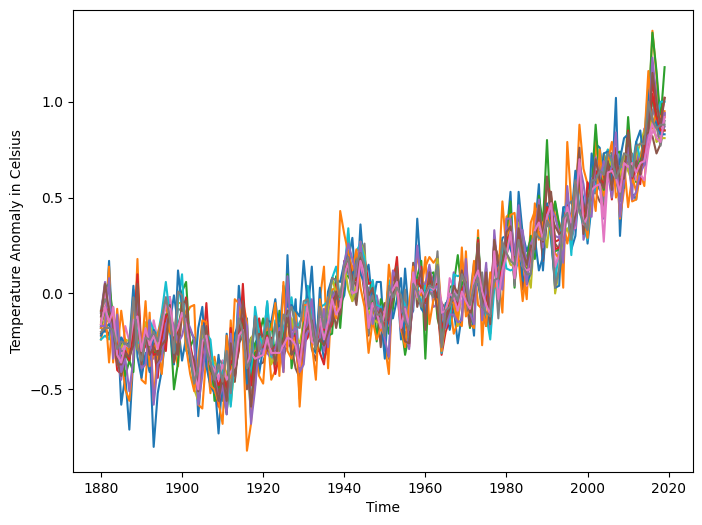

In [10]:
# set figsize = (x,y), and xy and y labels, and plot GIS TEMP
plt.figure(figsize= (8,6))
plt.xlabel('Time')
plt.ylabel('Temperature Anomaly in Celsius')
plt.plot(df1)

<Axes: xlabel='Year'>

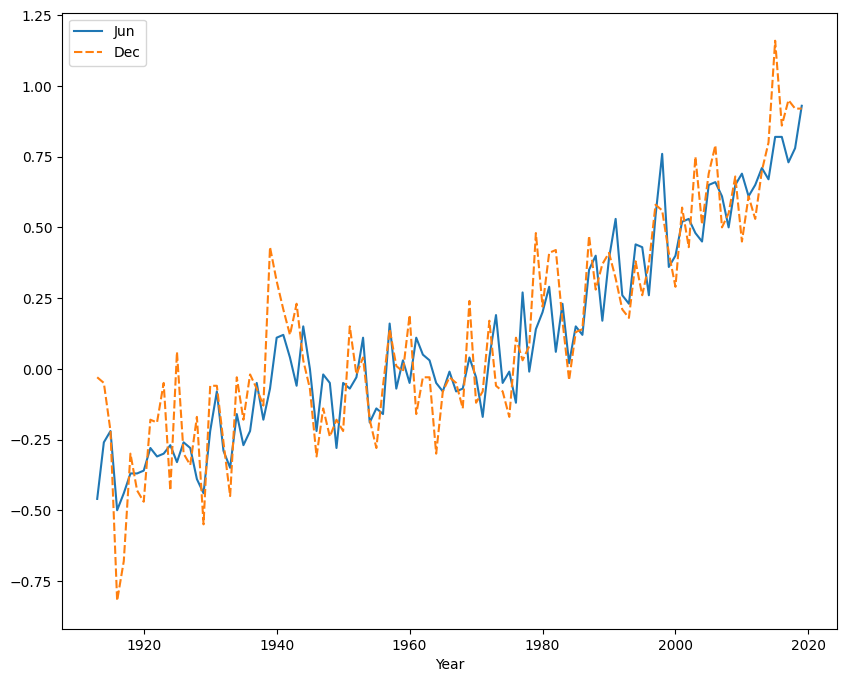

In [11]:
# use seaborn (sns) lineplot to plot Jun & Dec starting in '1913' (ford model T 1st year)
plt.figure(figsize= (10,8))
# loc[<index>, <column>]
sns.lineplot(data = [df1.loc['1913':,'Jun'],df1.loc['1913':,'Dec']])

<Axes: xlabel='Year'>

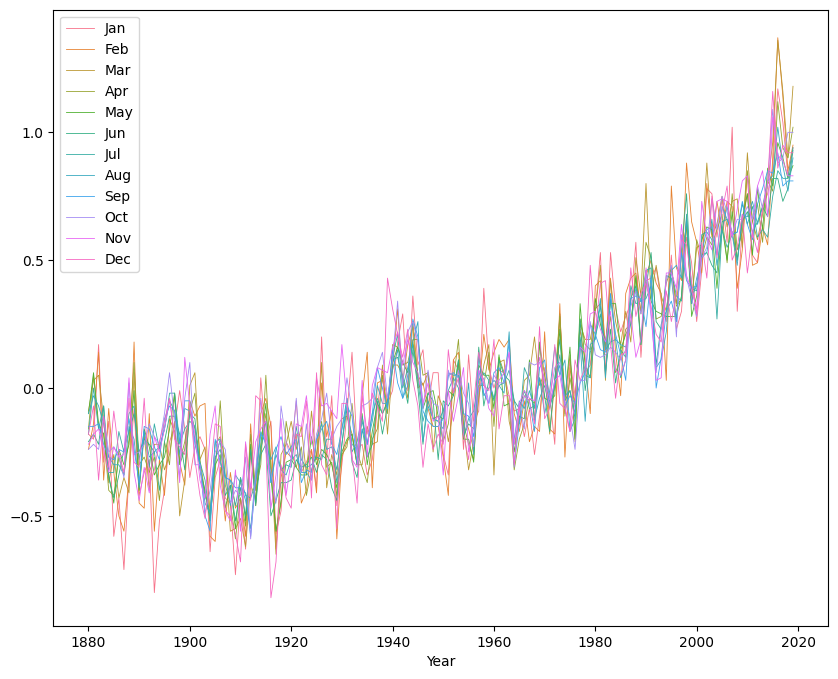

In [12]:
# use seaborn (sns) lineplot to plot Jun & Dec temp data with 0.6 linewidth
#  and disable dash lines (by default, up to 6 lines may use dashes)
plt.figure(figsize= (10,8))
# loc[<index>, <column>]
sns.lineplot(data = df1.loc[:,'Jan' : 'Dec'], linewidth = 0.6, dashes = False)

In [13]:
# display available styles (since 'seaborn' does not work)
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


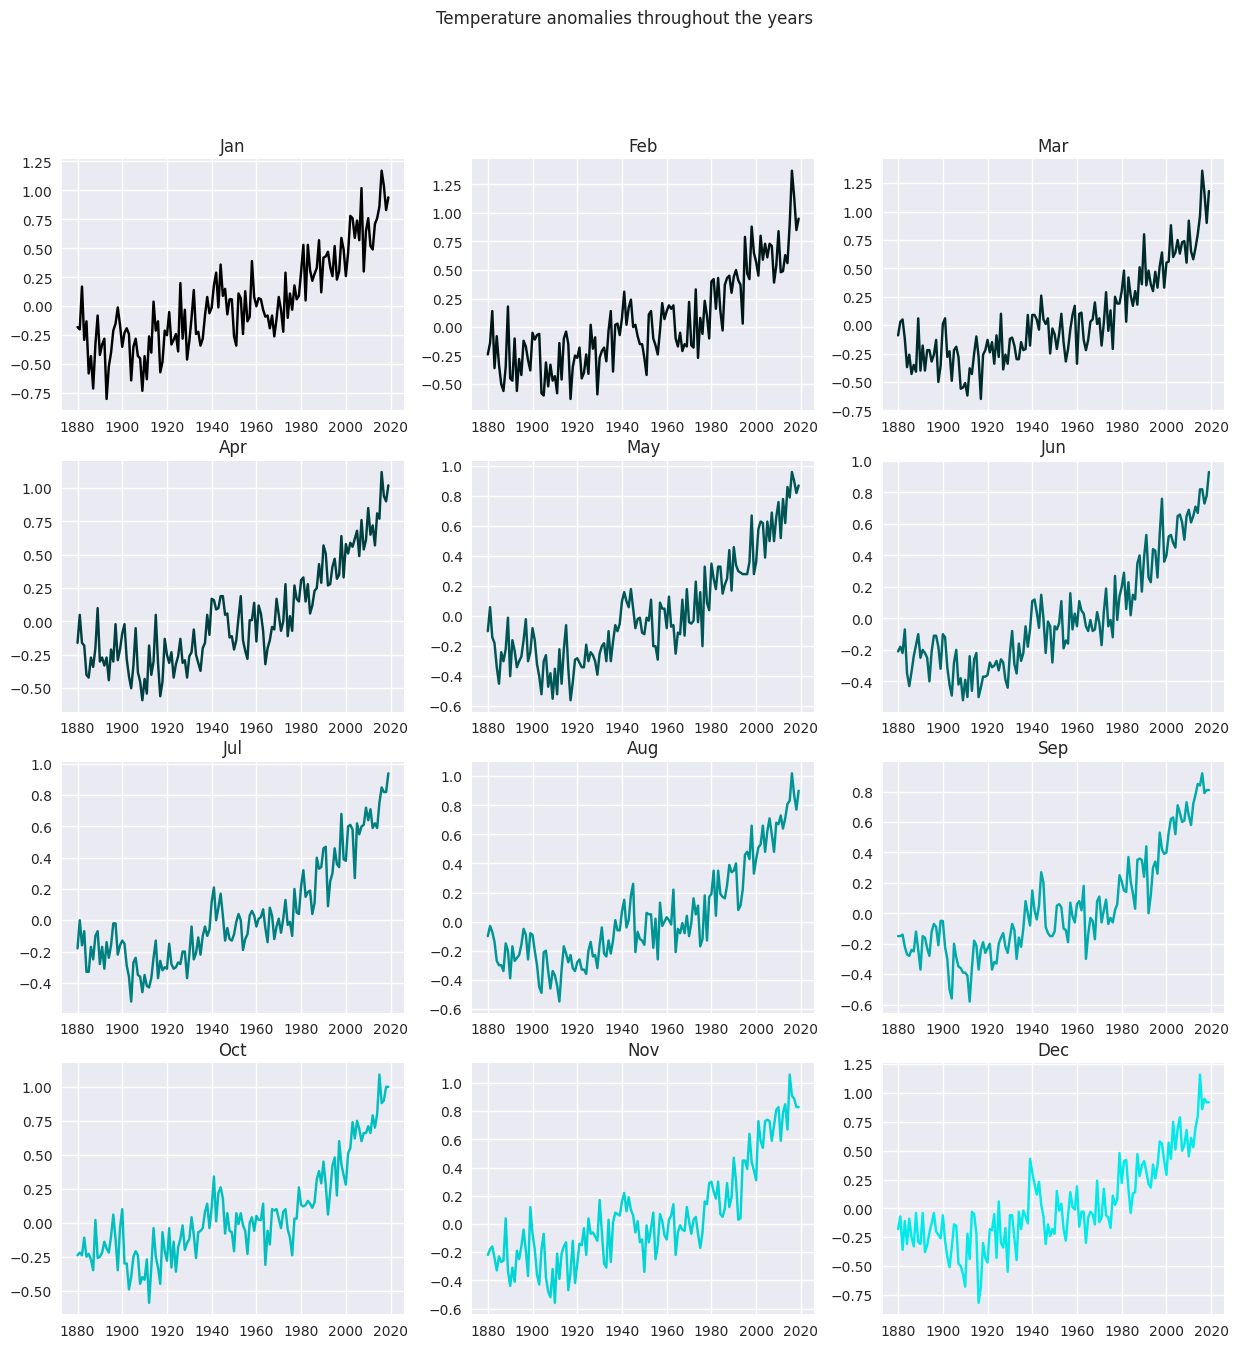

In [14]:
# create subplots with style context set to seaborn-v0_8
# generate 12 subplots (1 per month) with 4 rows and 3 columns
# plot color=(<red>,<green>,<blue>,<alpha>) where the values are floating points between 0 and 1
with plt.style.context('seaborn-v0_8'):
    fig, axes = plt.subplots(4,3, figsize=(15,15))
    # super title, suptitle(), is title at top
    fig.suptitle("Temperature anomalies throughout the years")
    col = 0
    for i in range (4):
        for j in range(3):
            # create 3 subplots per row
            axes[i,j].plot(df1.index, df1.loc[:, df1.columns[col]], color = (0, col/12, col/12, 1))
            axes[i,j].set_title(df1.columns[col])
            col += 1
            

<Axes: ylabel='Year'>

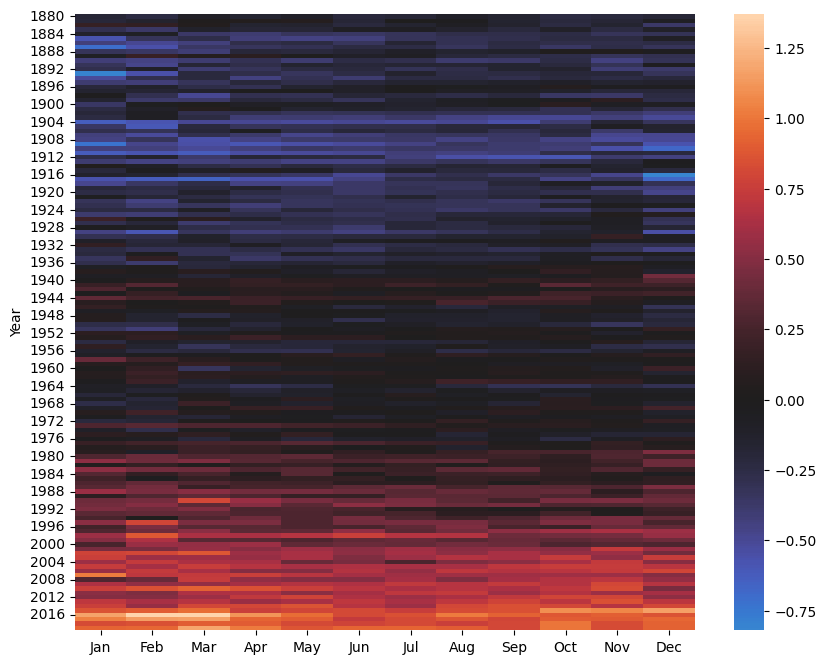

In [15]:
# create a heat map - centered on "0" value (center=0)
# use integer column indexing (e.g. iloc())
plt.figure(figsize= (10,8))
sns.heatmap(df1.iloc[:,0:12], center = 0)

In [16]:
# display seaborn colormap value for "RdBu_r" (Rd: red, Bu: Blue, _r: end with red))
sns.color_palette("RdBu_r")

[(0.18431372549019615, 0.4726643598615917, 0.7116493656286045),
 (0.5300269127258748, 0.7456362937331797, 0.8560553633217993),
 (0.8605151864667436, 0.9174163783160324, 0.9487120338331411),
 (0.9856978085351789, 0.8889657823913879, 0.8320645905420991),
 (0.9407151095732411, 0.609919261822376, 0.481276432141484),
 (0.7561707035755478, 0.21038062283737025, 0.22352941176470587)]

<Axes: ylabel='Year'>

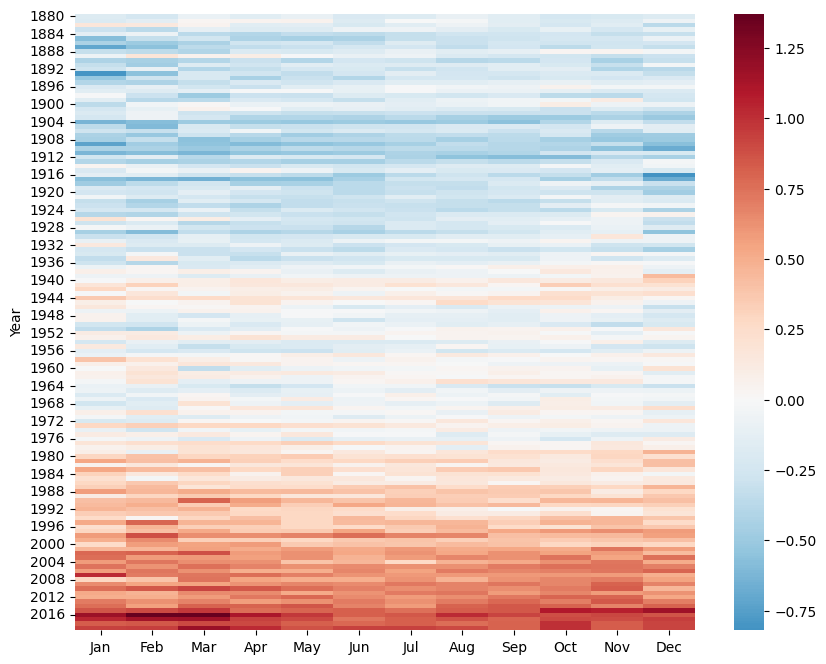

In [17]:
# create a heat map - centered on "0" value (center=0) plus specify "RdBu_r" color map (cmap)
# use integer column indexing (e.g. iloc())
plt.figure(figsize= (10,8))
sns.heatmap(df1.iloc[:,0:12], cmap = 'RdBu_r', center = 0)

<Axes: ylabel='Year'>

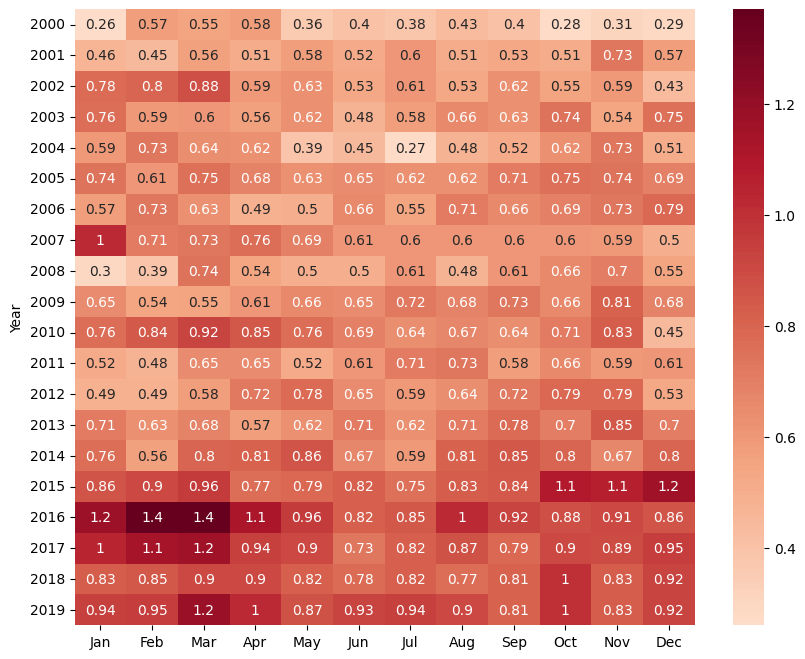

In [18]:
# heatmap using loc() to specify years: 2000 - 2019 from Jan - Dec 
#  plus annotate values to heatmap (annot=True)
plt.figure(figsize= (10,8))
sns.heatmap(df1.loc['2000':'2019','Jan' : 'Dec'], cmap = 'RdBu_r', center = 0, annot=True)

In [19]:
# install plotlib via installing "chart_studio" - includes interactive graphics
#!pip3 install chart_studio

In [20]:
# import plotly (chart_studio)
import plotly.graph_objects as go

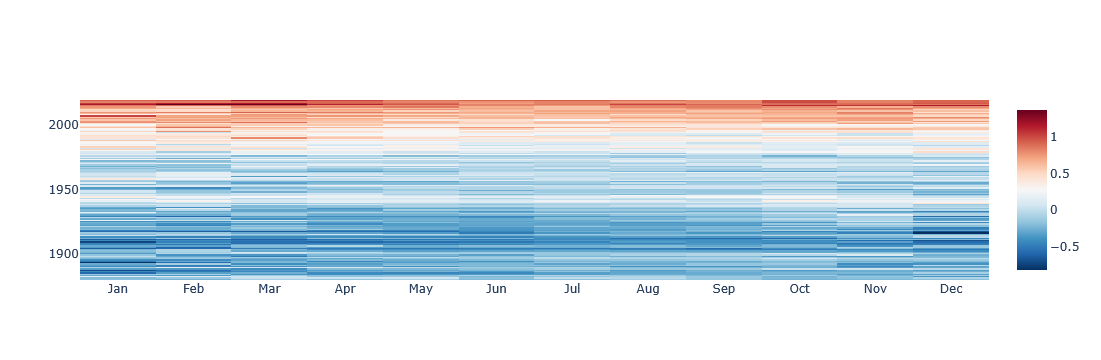

In [23]:
# re-do seaborn heatmap with Plotly heatmap which creates an interactive heatmap
#   dimensions: z: data, x: months, y: years
go.Figure(data = go.Heatmap(z = df1, x = df1.columns[0:12], y = df1.index, colorscale = 'rdbu', reversescale=True))

In [ ]:
# use mouse to zoom in or out of interactive heatmap or use zoom and other options in upper left corner
# hover over anywhere on map to see actual values

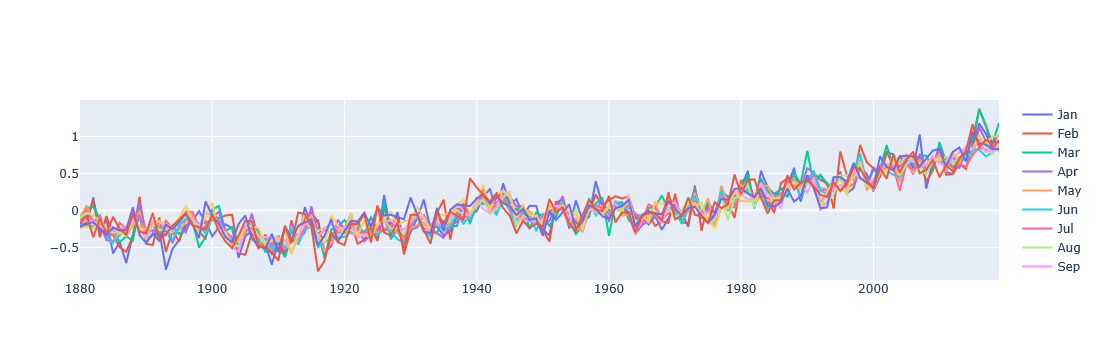

In [24]:
# create plotly interactive Scatter plot with a trace for each month
fig = go.Figure()
col = 0
for col in range(12):
    fig.add_trace(go.Scatter(x = df1.index, y = df1.loc[:, df1.columns[col]], name = df1.columns[col]))
    col += 1
fig.show()

In [ ]:
# can turn off plots by clicking month labels on right side